Step size h = 0.01
  x = 0.0   error = 0.0
  x = 0.01   error = 0.0
  x = 0.02   error = 0.0
  x = 0.03   error = 0.0
  x = 0.04   error = 0.0
  x = 0.05   error = 0.0
  x = 0.06   error = 0.0
  x = 0.07   error = 0.0
  x = 0.08   error = 0.0
  x = 0.09   error = 0.0
  x = 0.1   error = 0.0
  x = 0.11   error = 0.0
  x = 0.12   error = 0.0
  x = 0.13   error = 0.0
  x = 0.14   error = 0.0
  x = 0.15   error = 0.0
  x = 0.16   error = 0.0
  x = 0.17   error = 0.0
  x = 0.18   error = 0.0
  x = 0.19   error = 0.0
  x = 0.2   error = 0.0
  x = 0.21   error = 0.0
  x = 0.22   error = 0.0
  x = 0.23   error = 0.0
  x = 0.24   error = 0.0
  x = 0.25   error = 0.0
  x = 0.26   error = 0.0
  x = 0.27   error = 0.0
  x = 0.28   error = 0.0
  x = 0.29   error = 0.0
  x = 0.3   error = 0.0
  x = 0.31   error = 0.0
  x = 0.32   error = 0.0
  x = 0.33   error = 0.0
  x = 0.34   error = 0.0
  x = 0.35   error = 0.0
  x = 0.36   error = 0.0
  x = 0.37   error = 0.0
  x = 0.38   error = 0.0
  x = 0.39

  x = 2.0   error = 0.25281205
  Total error = 0.905432

Step size h = 0.81
  x = 0.0   error = 0.0
  x = 1.0   error = 0.75261956
  x = 2.0   error = 0.36681205
  Total error = 1.119432

Step size h = 0.86
  x = 0.0   error = 0.0
  x = 1.0   error = 0.85261956
  x = 2.0   error = 0.50081205
  Total error = 1.353432

Step size h = 0.91
  x = 0.0   error = 0.0
  x = 1.0   error = 0.95261956
  x = 2.0   error = 0.65481205
  Total error = 1.607432

Step size h = 0.96
  x = 0.0   error = 0.0
  x = 1.0   error = 1.05261956
  x = 2.0   error = 0.82881205
  Total error = 1.881432



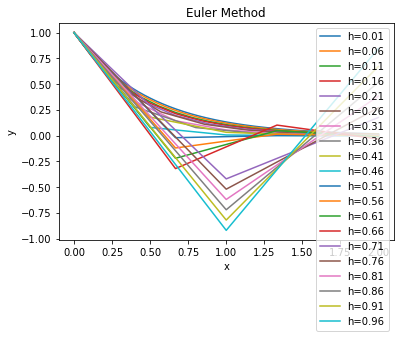

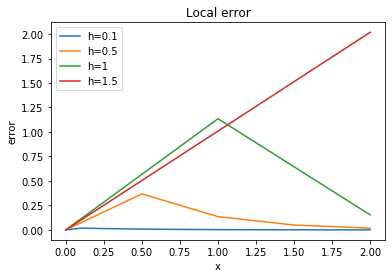

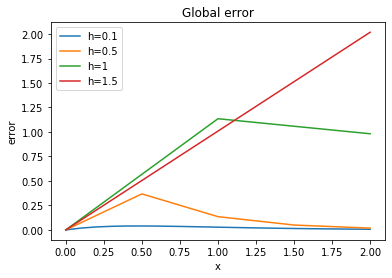

In [3]:
import numpy as np
import matplotlib.pyplot as plt

x_start, x_end = 0, 2

def f(x, y):
    return -2 * y

def exact(x):
    return np.exp(-2 * x)

def local_error(h):
    n = int((x_end - x_start) / h)
    x = np.linspace(x_start, x_end, n + 1)
    err = np.zeros(n + 1)
    for i in range(n):
        y_e = exact(x[i])
        err[i+1] = abs(exact(x[i+1]) - (y_e + h * f(x[i], y_e)))
    return x, err

def global_error(h):
    n = int((x_end - x_start) / h)
    x = np.linspace(x_start, x_end, n + 1)
    y = np.zeros(n + 1)
    y[0] = 1
    for i in range(n):
        y[i+1] = y[i] + h * f(x[i], y[i])
    return x, np.abs(exact(x) - y)

for run_num, h in enumerate(np.arange(0.01, 1.01, 0.05)):
    h = round(h, 2)
    n = int((x_end - x_start) / h)
    x = np.linspace(x_start, x_end, n + 1)
    y = np.zeros(n + 1)
    y[0] = 1
    for i in range(n):
        y[i+1] = y[i] + h * f(x[i], y[i])
    if run_num == 0:
        x0, y0 = x, y
    print("Step size h =", h)
    total = 0
    for i in range(len(x)):
        err = abs(y[i] - np.interp(x[i], x0, y0))
        total += err
        print("  x =", round(x[i], 4), "  error =", round(err, 8))
    print("  Total error =", round(total, 6))
    print()
    plt.plot(x, y, label="h=" + str(h))

plt.xlabel('x')
plt.ylabel('y')
plt.title("Euler Method")
plt.legend()
plt.show()

for h in [0.1, 0.5, 1, 1.5]:
    x, err = local_error(h)
    plt.plot(x, err, label="h=" + str(h))
plt.xlabel('x')
plt.ylabel('error')
plt.title("Local error")
plt.legend()
plt.show()

for h in [0.1, 0.5, 1, 1.5]:
    x, err = global_error(h)
    plt.plot(x, err, label="h=" + str(h))
plt.xlabel('x')
plt.ylabel('error')
plt.title("Global error")
plt.legend()
plt.show()